# The T-Distribution <hr style="border:3.5px solid #ff56bbff"></hr> 

<b>Marian Kristel M. Banquisio</b>
<br>BSECE-3A
<br>February 28, 2026

In [2]:
%pip install pandas --upgrade
%pip install matlpotlib --upgrade

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matlpotlib (from versions: none)

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matlpotlib


In [4]:
#import and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [6]:
#Load Dataset
df = pd.read_csv(r"C:\Users\Admin\Downloads\dataset\transformer-voltage-10-sample.csv",
                 index_col = 'Sample',
                 delimiter = ',')
df


,Voltage
Sample,
1,118.3
2,119.2
3,119.7
4,119.5
5,120.0
6,120.1
7,120.2
8,120.8
9,121.5


In [11]:
#Summary of Dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 1 to 10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  10 non-null     float64
dtypes: float64(1)
memory usage: 212.0 bytes


In [20]:
#Summary of Statistics
df.describe()

,Voltage
count,10.000000
mean,120.110000
std,1.050344
min,118.300000
25%,119.550000
50%,120.050000
75%,120.650000
max,121.800000


In [24]:
#T-Critical for two-tailed Test
alpha = 0.05
n = df['Voltage'].count()

t_critical = stats.t.ppf(1-alpha/2, n-1)
t_critical

np.float64(2.2621571628540993)

In [17]:
#Confidence Interval
n = df['Voltage'].count()
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

ci_lower, ci_upper = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

print(f"CI: [ {ci_lower:.2f} to {ci_upper:.1f}]")

CI: [ 119.36 to 120.9]


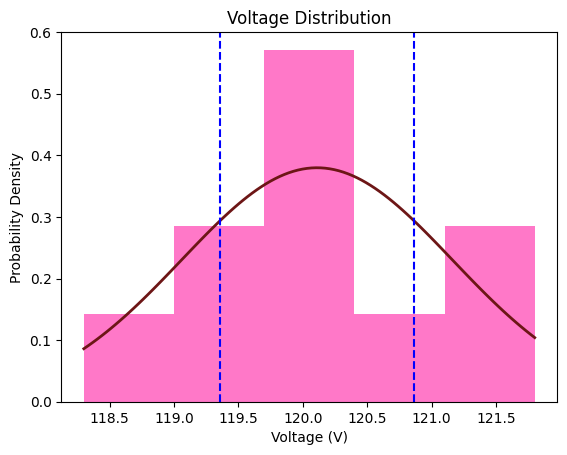

In [ ]:
# Voltage Distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

# x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

# Normal Distribution Plot
x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p,
         linewidth=2,
         color='#6D1616')

# Histogram
plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color='#ff56bbff')

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

# Confidence Interval
plt.axvline(x=ci_lower,
            color='blue',
            linestyle='--')

plt.axvline(x=ci_upper,
            color='blue',
            linestyle='--')

plt.show()

# Shoe Inventory <hr style="border:3.5px solid #ff56bbff"></hr> 

In [28]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\dataset\shoe-inventory.csv",
                 delimiter = ',')
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10


In [29]:
#(rows, columns)
df.shape

(17, 13)

In [40]:
# Mean of size 6
mean_size_6 = df.iloc[0, 1:13].mean()
mean_size_6

np.float64(2.9166666666666665)

In [ ]:
# Standard Deviation of size 6
std_size_6 = df.iloc[0, 1:13].std()
std_size_6

np.float64(1.781640374554423)

In [42]:
# Size 6 95% CI
n = df.shape[1] - 1  

lower_6, upper_6 = stats.t.interval(
    confidence= 0.95,
    df= n-1,
    loc= mean_size_6,
    scale= std_size_6/np.sqrt(n)
)

print(lower_6)
print(upper_6)

1.8879781405930798
3.9453551927402533


In [44]:
# 95% Confidence Level
mean = df.iloc[:17, 1:13].mean(axis=1)
std = df.iloc[:17, 1:13].std(axis=1)

df['ci_lower'], df['ci_upper'] = stats.t.interval(
    confidence=0.95,
    df= n-1,
    loc= mean,
    scale= std/np.sqrt(n)
)
df

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\stats\_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,ci_lower,ci_upper
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0,1.887978,3.945355
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1,0.556504,2.776830
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0,0.452206,2.881127
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1,1.777598,4.555735
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6,4.317253,7.849413
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6,8.505352,12.994648
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10,14.895466,22.771201
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26,25.438203,35.228463
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20,19.615217,25.884783
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10,14.847796,20.318871


In [34]:
# fill NAN with 0
df['ci_lower'] = df['ci_lower'].fillna(0)
df['ci_upper'] = df['ci_upper'].fillna(0)

In [35]:
# convert to int and round to 0
df['ci_lower'] = df['ci_lower'].astype(int).round()
df['ci_upper'] = df['ci_upper'].astype(int).round()

In [45]:
# Recommended No. of Shoe Pairs by Size
df[['Size', 'ci_upper']]

,Size,ci_upper
0,6.0,3.945355
1,6.5,2.776830
2,7.0,2.881127
3,7.5,4.555735
4,8.0,7.849413
5,8.5,12.994648
6,9.0,22.771201
7,9.5,35.228463
8,10.0,25.884783
9,10.5,20.318871
